In [1]:
import wandb
import pandas as pd
import os, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math

In [2]:
#qwen run functions
def plot_image_rows(
        sources,
        title=None,
        chunk_size=4,
        max_images_per_source=None,
        samples=2000,
        cache_dir=".wandb_media_cache",
        figsize_per_img=(4.2, 4.2),
        local_extensions=("*.png", "*.jpg", "*.jpeg", "*.webp"),
        local_recursive=False,
):
    api = wandb.Api()
    os.makedirs(cache_dir, exist_ok=True)

    def _is_wandb_image_obj(x):
        return isinstance(x, dict) and (x.get("_type") == "image-file" or "path" in x)

    def _download_and_open(run, img_obj):
        path = img_obj.get("path")
        if not path:
            return None

        local_path = os.path.join(cache_dir, path)

        if not os.path.exists(local_path):
            try:
                os.makedirs(os.path.dirname(local_path), exist_ok=True)
                run.file(path).download(root=cache_dir, replace=True)
            except Exception as e:
                print(f"download failed for {path}: {e}")
                return None

        try:
            with Image.open(local_path) as im:
                return im.convert("RGB").copy()
        except Exception as e:
            print(f"open failed for {local_path}: {e}")
            return None

    def _load_local_images(folder, file_glob=None):
        if not os.path.isdir(folder):
            print(f"local_folder not found: {folder}")
            return []

        patterns = [file_glob] if file_glob else list(local_extensions)

        paths = []
        for pat in patterns:
            if local_recursive:
                paths.extend(glob.glob(os.path.join(folder, "**", pat), recursive=True))
            else:
                paths.extend(glob.glob(os.path.join(folder, pat)))

        paths = sorted(set(paths))
        if max_images_per_source is not None:
            paths = paths[:max_images_per_source]

        imgs = []
        for p in paths:
            try:
                with Image.open(p) as im:
                    imgs.append(im.convert("RGB").copy())
            except Exception as e:
                print(f"failed to open local image {p}: {e}")
        return imgs

    rows = []

    for src in sources:
        label = src.get("label")

        if "local_folder" in src:
            folder = src["local_folder"]
            if label is None:
                label = folder
            imgs = _load_local_images(folder, file_glob=src.get("glob"))
            rows.append({"label": label, "images": imgs})
            continue

        # W&B
        run_path = src.get("run")
        if not run_path:
            raise ValueError("Each W&B source must include 'run' OR use 'local_folder'.")

        if label is None:
            label = run_path

        run = api.run(run_path)
        metric = src.get("metric")
        prefix = src.get("wandb_prefix")

        if metric and prefix:
            raise ValueError("Provide either 'metric' OR 'wandb_prefix' (not both).")

        # W&B metric over time
        if metric:
            hist = run.history(keys=[metric], samples=samples)
            if hist.empty or metric not in hist.columns:
                print(f"{run_path}: metric '{metric}' not found/empty")
                rows.append({"label": label, "images": []})
                continue

            series = hist[metric].dropna()
            imgs = []
            for x in series.tolist():
                if _is_wandb_image_obj(x):
                    im = _download_and_open(run, x)
                    if im is not None:
                        imgs.append(im)

            if max_images_per_source is not None:
                imgs = imgs[-max_images_per_source:]
            rows.append({"label": label, "images": imgs})
            continue

        if prefix:
            hist0 = run.history(keys=None, samples=min(samples, 200))
            if hist0.empty:
                print(f"{run_path}: history empty")
                rows.append({"label": label, "images": []})
                continue

            keys = [c for c in hist0.columns if isinstance(c, str) and c.startswith(prefix)]
            if not keys:
                print(f"{run_path}: no keys with prefix '{prefix}'")
                rows.append({"label": label, "images": []})
                continue

            hist = run.history(keys=keys, samples=samples)

            imgs = []
            for k in sorted(keys):
                if k not in hist.columns:
                    continue
                s = hist[k].dropna()

                last_img_obj = None
                for x in reversed(s.tolist()):
                    if _is_wandb_image_obj(x):
                        last_img_obj = x
                        break

                if last_img_obj is not None:
                    im = _download_and_open(run, last_img_obj)
                    if im is not None:
                        imgs.append(im)

            if max_images_per_source is not None:
                imgs = imgs[:max_images_per_source]
            rows.append({"label": label, "images": imgs})
            continue

        raise ValueError("Each source must specify 'metric', 'wandb_prefix', or 'local_folder'.")

    n_sources = len(rows)
    max_len = max((len(r["images"]) for r in rows), default=0)
    if max_len == 0:
        print("images found in any source.")
        return

    n_chunks = math.ceil(max_len / chunk_size)
    nrows = n_chunks * n_sources
    ncols = chunk_size

    fig_w = ncols * figsize_per_img[0]
    fig_h = nrows * figsize_per_img[1]
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), squeeze=False)

    def _row_index(chunk_idx, source_idx):
        # chunk0: src0 row0, src1 row1, ...
        # chunk1: src0 rowN, src1 rowN+1, ...
        return chunk_idx * n_sources + source_idx

    for chunk_idx in range(n_chunks):
        start = chunk_idx * chunk_size
        end = start + chunk_size

        for s_idx, row in enumerate(rows):
            rr = chunk_idx * n_sources + s_idx
            imgs = row["images"][start:end]

            for c in range(ncols):
                ax = axes[rr][c]
                ax.axis("off")

                if c == 0:
                    ax.text(
                        -0.15, 0.5,
                        row["label"],
                        transform=ax.transAxes,
                        ha="right",
                        va="center",
                        fontsize=12,
                        fontweight="bold",
                    )

                if c < len(imgs):
                    ax.imshow(imgs[c])
                    ax.set_title(f"image {start + c}", fontsize=10)

    if title:
        fig.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()




In [3]:
#qwen run functions
def plot_wandb_runs(
        run_paths,
        metric,
        labels=None,
        title=None,
        smooth_window=None,
        samples=2000,
        figsize=(7, 4),
        xlabel="Step",
        ylabel=None,
        x_values=None,
):
    api = wandb.Api()

    if labels is None:
        labels = run_paths
    assert len(labels) == len(run_paths), "labels must match run_paths length"

    plt.figure(figsize=figsize)

    for path, label in zip(run_paths, labels):
        print(f"Loading {path} ...")
        run = api.run(path)

        hist = run.history(keys=[metric] + ([x_values] if isinstance(x_values, str) else []),
                           samples=samples)

        if hist.empty or metric not in hist.columns:
            print(f"{path}: metric '{metric}' not found")
            continue

        y_plot = hist[metric]
        y_stats = pd.to_numeric(hist[metric], errors="coerce").dropna()

        if len(y_stats) == 0:
            print(f"{path}: metric '{metric}' has no numeric values")
            continue

        if x_values is None:
            x = np.arange(len(y_plot))
        elif isinstance(x_values, str):
            if x_values not in hist.columns:
                print(f"{path}: x_values column '{x_values}' not found, fallback to index")
                x = np.arange(len(y_plot))
            else:
                x = hist[x_values].values
        else:
            x = np.asarray(x_values)
            if len(x) != len(y_plot):
                raise ValueError(f"x_values length ({len(x)}) must match y length ({len(y_plot)})")

        if smooth_window is not None:
            y_plot = y_plot.rolling(smooth_window, min_periods=1).mean()
            y_stats = y_stats.rolling(smooth_window, min_periods=1).mean()

        mean = float(y_stats.mean())
        std = float(y_stats.std())

        full_label = f"{label}  (mean: {mean:.3f} ± std: {std:.3f})"

        plt.plot(x, y_plot.values, label=full_label)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel if ylabel is not None else metric)
    plt.title(title if title else metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
#gsplat run functions
def plot_wandb_metric_compare_runs_plus_mean(
    runs_a,
    runs_b,
    *,
    metric: str,
    title: str,
    xlabel: str,
    ylabel: str,
    label_a: str,
    label_b: str,
    x_key: str = "_step",
    samples: int = 5000,
    smooth_window: int | None = None,
    show_std: bool = True,
    alpha_runs: float = 0.25,
    alpha_band: float = 0.18,
    lw_runs: float = 1.0,
    lw_mean: float = 3.5,
    debug: bool = False,
):
    def get_series(run):
        df = run.history(samples=samples)
        if df is None or df.empty:
            if debug:
                print(f"[skip] {run.name}: history is empty")
            return None

        if x_key not in df.columns or metric not in df.columns:
            if debug:
                print(f"[skip] {run.name}: missing required columns")
            return None

        d = df[[x_key, metric]].dropna()
        d[x_key] = pd.to_numeric(d[x_key], errors="coerce")
        d[metric] = pd.to_numeric(d[metric], errors="coerce")
        d = d.dropna().sort_values(x_key)

        if len(d) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few points")
            return None

        s = d.set_index(x_key)[metric]
        s = s[~s.index.duplicated(keep="last")]
        if len(s) <= 1:
            if debug:
                print(f"[skip] {run.name}: too few unique steps")
            return None

        if debug:
            print(f"[ok] {run.name}: {len(s)} points")
        return s

    def build_group(runs):
        series_list = []
        for r in runs:
            s = get_series(r)
            if s is not None:
                series_list.append(s)

        if not series_list:
            return None, None, None

        x_all = np.array(sorted(set().union(*[s.index.to_numpy() for s in series_list])))
        x_all = x_all[~np.isnan(x_all)]
        if x_all.size == 0:
            return None, None, None

        mat = []
        for s in series_list:
            y = s.reindex(x_all).interpolate(method="index", limit_direction="both")
            mat.append(y.to_numpy())

        M = np.vstack(mat)
        return x_all, M, series_list

    def smooth(y):
        if smooth_window is None or smooth_window <= 1:
            return y
        return (
            pd.Series(y)
            .rolling(smooth_window, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

    def plot_group(x, M, series_list, *, color, label):
        for s in series_list:
            plt.plot(
                s.index,
                s.values,
                color=color,
                linewidth=lw_runs,
                alpha=alpha_runs,
            )

        mean = smooth(np.nanmean(M, axis=0))
        std = np.nanstd(M, axis=0)

        plt.plot(
            x,
            mean,
            color=color,
            linewidth=lw_mean,
            label=f"{label} (mean, n={M.shape[0]})",
        )

        if show_std:
            plt.fill_between(
                x,
                mean - std,
                mean + std,
                color=color,
                alpha=alpha_band,
                linewidth=0,
            )

    x_a, M_a, series_a = build_group(runs_a)
    x_b, M_b, series_b = build_group(runs_b)

    plt.figure()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plotted = False

    if M_a is not None:
        plot_group(x_a, M_a, series_a, color="C0", label=label_a)
        plotted = True

    if M_b is not None:
        plot_group(x_b, M_b, series_b, color="C1", label=label_b)
        plotted = True

    if not plotted:
        raise ValueError(
            f"No plottable data found. Check metric='{metric}' and x_key='{x_key}'."
        )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
wandb.login()
api = wandb.Api()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\flori\.netrc.
wandb: Currently logged in as: floowbaumgartner (vton_pipeline) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [10]:
api = wandb.Api()
entity = "vton_pipeline"
project = "vton_lora_exp"

runs = api.runs(f"{entity}/{project}")

n1_runs = []

for r in runs:
    name = (r.name or "").lower()

    if "can_shirt" in name:
        n1_runs.append(r)

print("n1_runs:", len(n1_runs))

n1_runs: 3


In [11]:
api = wandb.Api()
entity = "vton_pipeline"
project = "vton_vggt_param_tune"

runs = api.runs(f"{entity}/{project}")

tune_runs = []

for r in runs:
    name = (r.name or "").lower()

    if "olive-sweep-158" in name:
        tune_runs.append(r)

print("tune_runs:", len(tune_runs))

tune_runs: 1


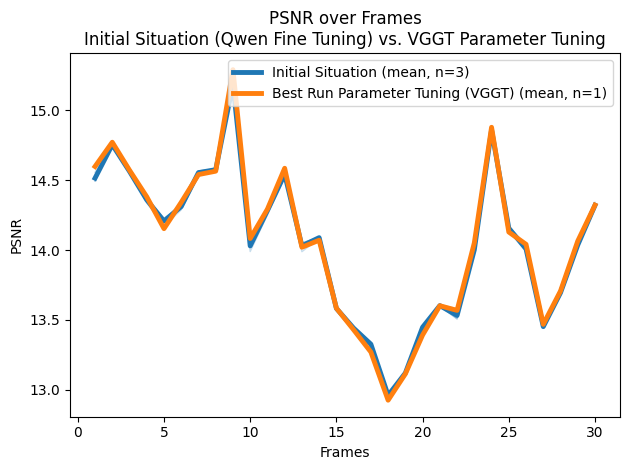

In [13]:
plot_wandb_metric_compare_runs_plus_mean(
    n1_runs,
    tune_runs,
    metric="vggt/psnr",
    title="PSNR over Frames\nInitial Situation (Qwen Fine Tuning) vs. VGGT Parameter Tuning",
    xlabel="Frames",
    ylabel="PSNR",
    label_a="Initial Situation",
    label_b="Best Run Parameter Tuning (VGGT)",
    x_key="_step",
    show_std=False,
    samples=5000,
    debug=False,
)